# Customer Segmentation project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [2]:
data = pd.read_csv("C:/Users/abinj/OneDrive/Desktop/project/ML/custmer/online_shoppers_intention.csv")

In [3]:
print(data.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [4]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [6]:
x = data[['ProductRelated_Duration', 'BounceRates']].values

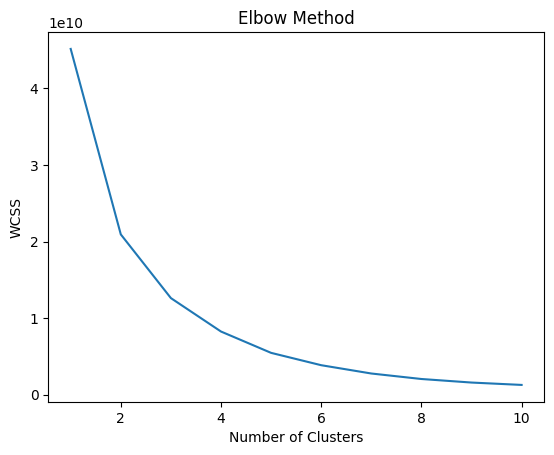

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )

    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
print(wcss)

[45150402566.281784, 20930348884.832726, 12613089025.29937, 8247424180.15259, 5462310754.873231, 3850785375.083143, 2767312059.3381577, 2049836346.7408214, 1586178430.3167734, 1276228312.578601]


In [9]:
km = KMeans(n_clusters=2, random_state=0)
y_means = km.fit_predict(x)

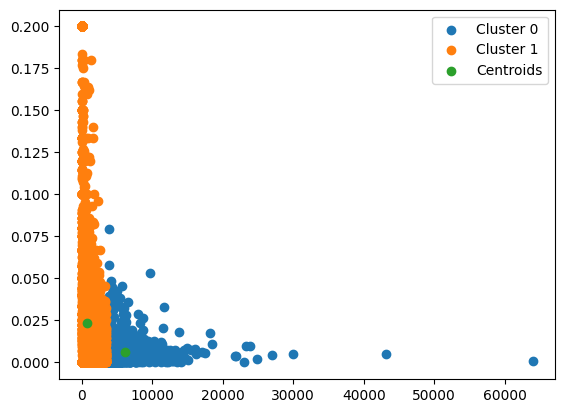

In [10]:
plt.scatter(
    x[y_means==0,0],
    x[y_means==0,1],
    label='Cluster 0'
)

plt.scatter(
    x[y_means==1,0],
    x[y_means==1,1],
    label='Cluster 1'
)

plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    label='Centroids'
)

plt.legend()
plt.show()

In [12]:
km = KMeans(
    n_clusters=i,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)

In [13]:
n_clusters=2

In [14]:
km.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [15]:
labels = km.labels_

In [16]:
wcss.append(km.inertia_)

In [18]:
print(len(wcss))

11


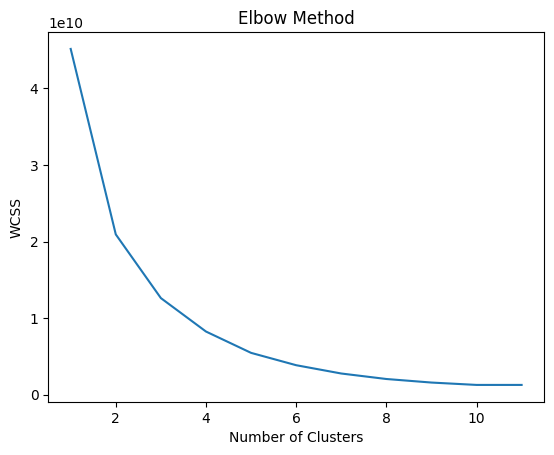

In [19]:
plt.plot(range(1, len(wcss)+1), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [20]:
wcss = []

for i in range(1,12):   # 1 to 11
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

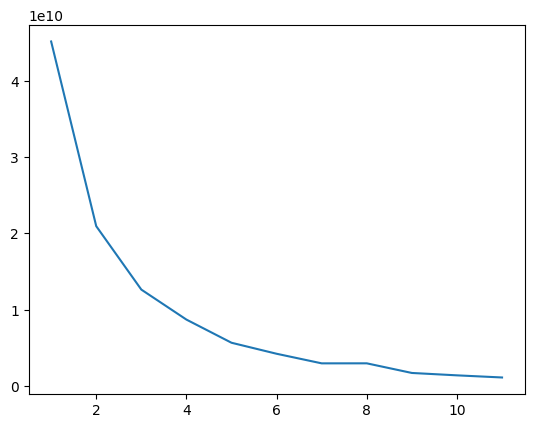

In [21]:
plt.plot(range(1,12), wcss)

In [22]:
print(len(wcss))
print(wcss)

11
[45150402566.281784, 20930411381.429394, 12613137570.71699, 8679895492.764305, 5641980710.560515, 4198760989.787835, 2940862116.7235975, 2943676230.8106666, 1680488184.2880425, 1367847771.9577775, 1088435643.281886]


In [23]:
km = KMeans(
    n_clusters=2,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)

In [24]:
y_means = km.fit_predict(x)

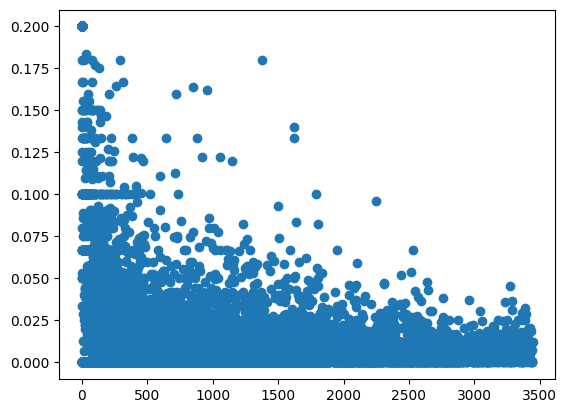

In [25]:
plt.scatter(
    x[y_means==0,0],
    x[y_means==0,1]
)

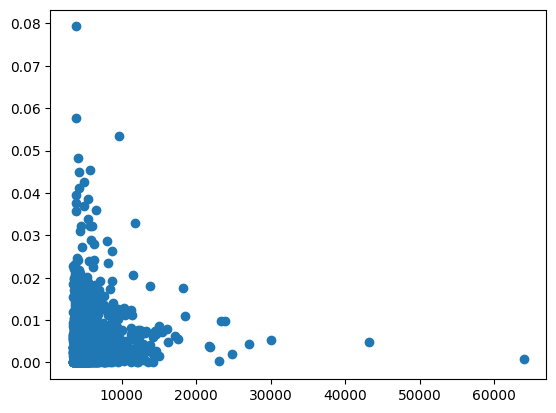

In [26]:
plt.scatter(
    x[y_means==1,0],
    x[y_means==1,1]
)

In [27]:
x[y_means==0]

array([[0.0000000e+00, 2.0000000e-01],
       [6.4000000e+01, 0.0000000e+00],
       [0.0000000e+00, 2.0000000e-01],
       ...,
       [1.8425000e+02, 8.3333333e-02],
       [3.4600000e+02, 0.0000000e+00],
       [2.1250000e+01, 0.0000000e+00]], shape=(11399, 2))

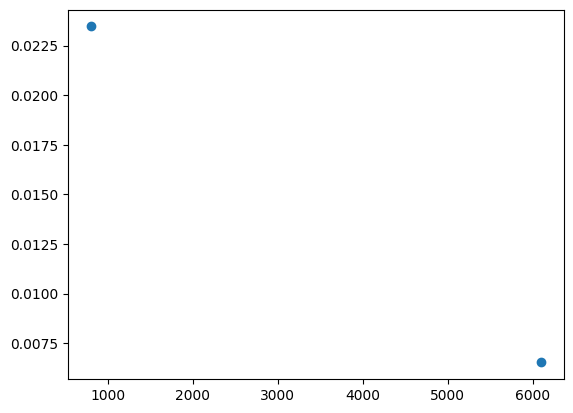

In [28]:
plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1]
)

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

labels_true = le.fit_transform(data['Revenue'])

In [32]:
labels_pred = y_means

In [33]:
from sklearn import metrics

score = metrics.adjusted_rand_score(
    labels_true,
    labels_pred
)

In [34]:
import scikitplot as skplt

skplt.metrics.plot_confusion_matrix(
    labels_true,
    labels_pred
)

ModuleNotFoundError: No module named 'scikitplot'

In [35]:
!pip install scikit-plot


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\abinj\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [36]:
import scikitplot as skplt

ImportError: cannot import name 'interp' from 'scipy' (C:\Users\abinj\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\__init__.py)

In [38]:
import scipy
print(scipy.__version__)

1.17.1


In [39]:
!pip install yellowbrick


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\abinj\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [40]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(X)
visualizer.show()

YellowbrickTypeError: The supplied model is not a clustering estimator; try a classifier or regression score visualizer instead!

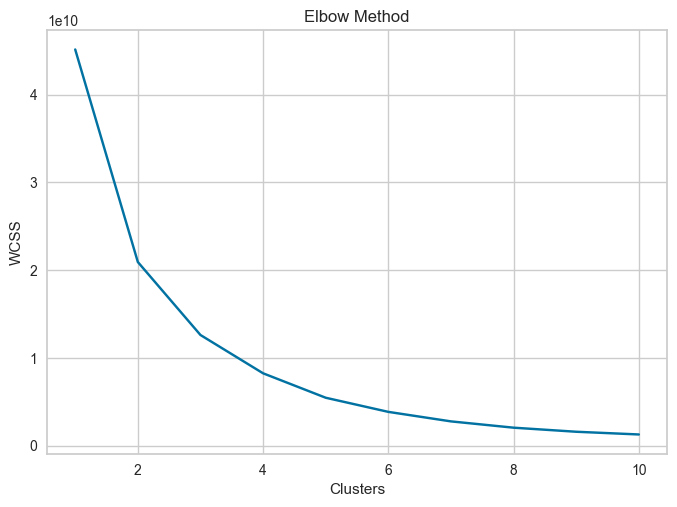

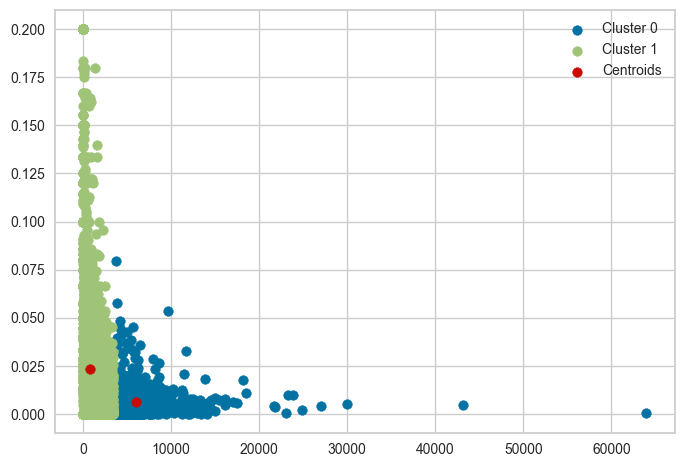

ARI: 0.08308038937907974


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

# Load dataset
data = pd.read_csv("online_shoppers_intention.csv")

# Features
x = data[['ProductRelated_Duration',
          'BounceRates']].values

# Elbow Method
wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )

    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# Final Model
km = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=0
)

y_means = km.fit_predict(x)

# Plot Clusters
plt.scatter(
    x[y_means==0,0],
    x[y_means==0,1],
    label="Cluster 0"
)

plt.scatter(
    x[y_means==1,0],
    x[y_means==1,1],
    label="Cluster 1"
)

plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    label="Centroids"
)

plt.legend()
plt.show()

# Evaluation
le = LabelEncoder()
labels_true = le.fit_transform(data['Revenue'])

score = metrics.adjusted_rand_score(
    labels_true,
    y_means
)

print("ARI:", score)

In [1]:
x = data[['ProductRelated_Duration',
          'BounceRates']]

NameError: name 'data' is not defined

In [2]:
x = data[[
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]]

NameError: name 'data' is not defined

In [7]:
print([var for var in locals() if not var.startswith('_')])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'StandardScaler', 'scaler']


In [8]:
import pandas as pd

data = pd.read_csv("C:/Users/abinj/OneDrive/Desktop/project/ML/custmer/online_shoppers_intention.csv")

In [9]:
x = data[[
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [11]:
print(type(data))
print(data.shape)
print(data.columns)

<class 'pandas.DataFrame'>
(12330, 18)
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')


In [16]:
data = pd.read_csv("C:/Users/abinj/OneDrive/Desktop/project/ML/custmer/online_shoppers_intention.csv")


In [17]:
print(x.shape)
print(x_scaled.shape)

(12330, 9)
(12330, 9)


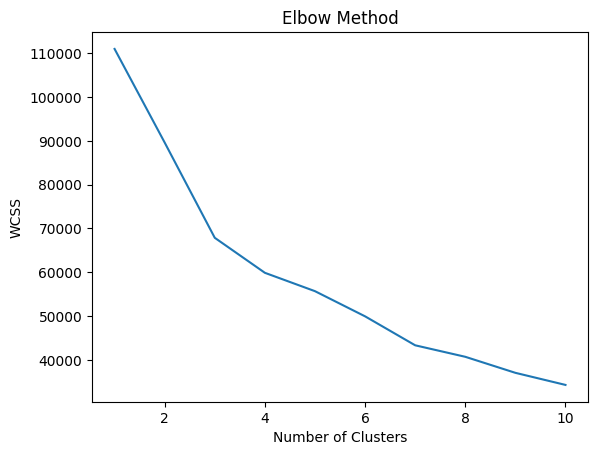

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [19]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(x_scaled)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [22]:
from sklearn.cluster import KMeans

km = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42
)

km.fit(x_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [23]:
print(type(km))

<class 'sklearn.cluster._kmeans.KMeans'>


In [24]:
# Cell 1
km = KMeans(n_clusters=4)

In [25]:
# Cell 5
km.fit(x_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [26]:
# 1. Import
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Select features
x = data[[
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]]

# 3. Scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 4. Train KMeans
km = KMeans(n_clusters=4, random_state=42)
km.fit(x_scaled)

# 5. Predict clusters
clusters = km.predict(x_scaled)

# 6. Add cluster labels
data['Cluster'] = clusters

print(data.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [27]:
print(data.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
Cluster                    0
dtype: int64


In [29]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    km = KMeans(n_clusters=k)
    labels = km.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)

    print(k, score)

2 0.4549482852946481
3 0.49425753882736007
4 0.2785425164197313
5 0.4046799404688532
6 0.42151324848452615
7 0.42180190653532784
8 0.41590634589138653
9 0.265179002672212
10 0.26502758664149917


In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

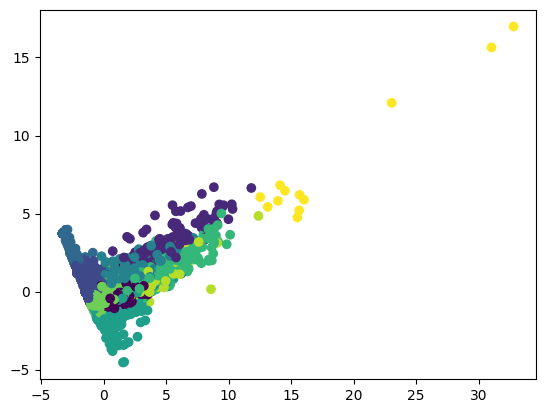

In [34]:
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=labels
)

In [35]:
data['Cluster'] = labels

In [39]:
numeric_cols = data.select_dtypes(include=['number']).columns
data.groupby('Cluster')[numeric_cols].mean()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Cluster
Cluster,,,,,,,,,,,,,,,
0,6.481303,196.725996,0.411325,13.706569,40.209402,1401.987398,0.006403,0.020300,5.454381,0.033761,2.091346,2.295406,3.248932,3.868056,0.0
1,6.201389,211.775848,4.430556,1017.535598,85.465278,3755.601344,0.007581,0.022053,8.354330,0.038889,2.097222,2.229167,2.930556,3.347222,1.0
2,0.276646,7.621128,0.066319,1.865309,9.147324,310.829347,0.029225,0.076927,0.333192,0.112838,2.132639,2.354334,3.118427,4.554240,2.0
3,0.020882,0.751353,0.008121,0.000000,2.259861,32.909996,0.185887,0.191849,0.000000,0.087935,2.170534,2.334107,3.127610,4.821346,3.0
4,4.995627,150.094383,3.743440,217.128089,48.695335,1863.225998,0.007753,0.022420,7.424668,0.031778,2.087464,2.110787,3.007289,3.661808,4.0
5,2.089524,65.347085,0.297143,14.985090,29.196190,1146.586696,0.002763,0.014815,73.628297,0.014095,2.173333,2.596190,3.249524,4.316190,5.0
6,6.479810,172.432775,1.610451,78.292109,184.159145,7140.672574,0.005318,0.017971,5.077099,0.049406,2.140143,2.372922,2.833729,3.491686,6.0
7,1.038930,27.785242,0.168092,6.043618,25.480444,945.948989,0.005136,0.023114,2.317280,0.058432,2.123886,2.395670,3.169547,3.931599,7.0
8,8.880000,1002.414833,1.210000,69.404173,51.595000,2306.088451,0.006556,0.020653,9.127346,0.017000,2.135000,2.295000,3.110000,3.800000,8.0


In [40]:
print(data['Cluster'].value_counts())

Cluster
7    5497
2    2111
0    1872
3     862
4     686
5     525
6     421
8     200
1     144
9      12
Name: count, dtype: int64


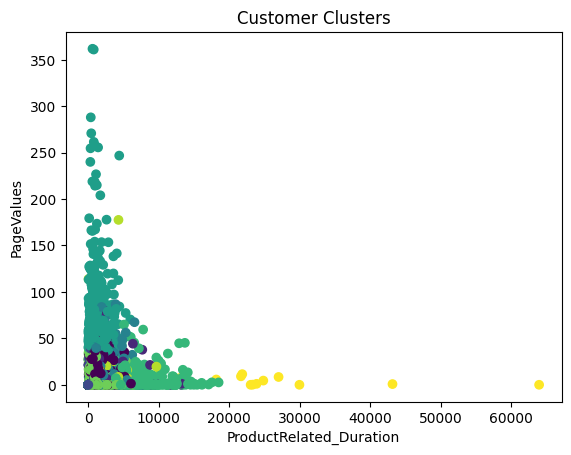

In [41]:
import matplotlib.pyplot as plt

plt.scatter(
    data['ProductRelated_Duration'],
    data['PageValues'],
    c=data['Cluster']
)

plt.xlabel('ProductRelated_Duration')
plt.ylabel('PageValues')
plt.title('Customer Clusters')
plt.show()

In [42]:
from sklearn.cluster import KMeans

In [43]:
from sklearn.cluster import DBSCAN

In [44]:
from sklearn.cluster import AgglomerativeClustering

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
pip install streamlit

  Using cached streamlit-1.58.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached cachetools-7.1.4-py3-none-any.whl.metadata (5.5 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached pyarrow-24.0.0-cp311-cp311-win_amd64.whl.metadata (3.0 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached httptools-0.8.0-cp311-cp311-win_amd64.whl.metadata (3.7 kB)
  Using cached websockets-16.0-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
Using cached streamlit-1.58.0-py3-none-any.whl (9.2 MB)
   ---------------------------------------- 0.0/797.5 kB ? eta


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\abinj\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip
